In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [19]:
ROOT_DIR = Path.cwd().parent

HIDDEN_SIZE_PATH = (
    ROOT_DIR
    / "reports"
    / "tables"
    / "rnn"
    / "caption_by_hidden_size.csv"
)

RECURRENT_LAYER_PATH = (
    ROOT_DIR
    / "reports"
    / "tables"
    / "rnn"
    / "caption_by_recurrent_layers.csv"
)

SAVE_DIR = (
    ROOT_DIR
    / "reports"
    / "figures"
    / "rnn"
)

RNN_TABLE_DIR = (
    ROOT_DIR
    / "reports"
    / "tables"
    / "rnn"
)

RESULT_PATH = (
    ROOT_DIR
    / "reports"
    / "tables"
    / "rnn"
    / "rnn_lstm_results.csv"
)

result_df = pd.read_csv(RESULT_PATH)

display(result_df.head())


SAVE_DIR.mkdir(parents=True, exist_ok=True)

,bleu4,epochs,eval_images,hidden_size,implementation,meteor,model_path,recur_layers,recur_type,time_s,weight_path
0,0.118380,10,1012,128,keras,0.317266,models/rnn/rnn_layers1_hidden128_len33.keras,1,rnn,45.368093,models/rnn/rnn_layers1_hidden128_len33.npz
1,0.159473,10,1012,512,keras,0.347779,models/rnn/rnn_layers1_hidden512_len33.keras,1,rnn,42.221393,models/rnn/rnn_layers1_hidden512_len33.npz
2,0.105427,10,1012,128,keras,0.302255,models/rnn/rnn_layers2_hidden128_len33.keras,2,rnn,68.292161,models/rnn/rnn_layers2_hidden128_len33.npz
3,0.136186,10,1012,512,keras,0.332347,models/rnn/rnn_layers2_hidden512_len33.keras,2,rnn,75.877472,models/rnn/rnn_layers2_hidden512_len33.npz
4,0.089541,10,1012,128,keras,0.304962,models/rnn/rnn_layers3_hidden128_len33.keras,3,rnn,112.622568,models/rnn/rnn_layers3_hidden128_len33.npz


In [5]:
hidden_df = pd.read_csv(HIDDEN_SIZE_PATH)
layer_df = pd.read_csv(RECURRENT_LAYER_PATH)

display(hidden_df)
display(layer_df)

,recur_type,hidden_size,bleu4,meteor,time_s
0,lstm,128,0.094245,0.291647,28.967563
1,lstm,512,0.132148,0.341621,44.040523
2,rnn,128,0.104450,0.308161,75.427607
3,rnn,512,0.142815,0.332255,64.064014


,recur_type,recur_layers,bleu4,meteor,time_s
0,lstm,1,0.116709,0.322017,35.407698
1,lstm,2,0.121905,0.325989,39.770666
2,lstm,3,0.100976,0.301897,34.333765
3,rnn,1,0.138927,0.332522,43.794743
4,rnn,2,0.120807,0.317301,72.084817
5,rnn,3,0.111163,0.310801,93.357873


In [6]:
def plot_metric_pairs(
    labels,
    left_values,
    right_values,
    left_label,
    right_label,
    title,
    ylabel,
    filename
):
    x = range(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 4))

    plt.bar(
        [i - width / 2 for i in x],
        left_values,
        width=width,
        label=left_label
    )

    plt.bar(
        [i + width / 2 for i in x],
        right_values,
        width=width,
        label=right_label
    )

    plt.xticks(list(x), labels)
    plt.xlabel("Configuration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(SAVE_DIR / filename, dpi=160)
    plt.show()

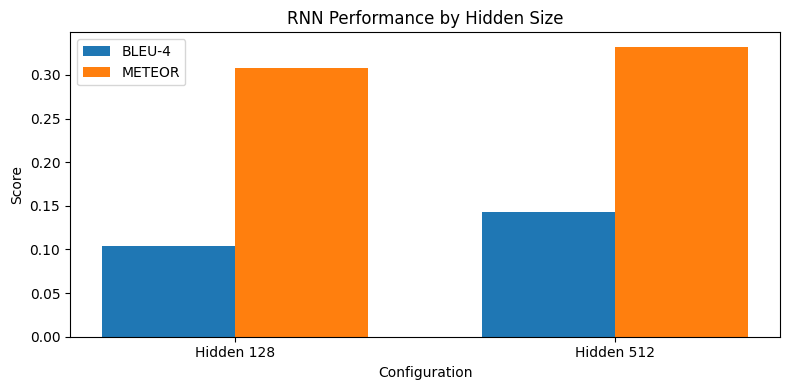

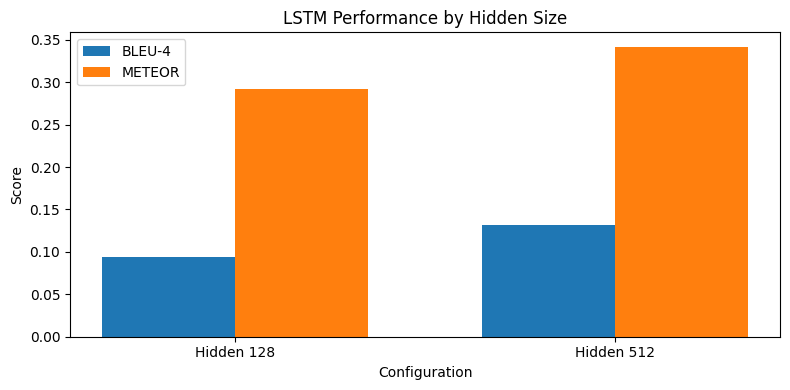

In [7]:
for recur_type in ["rnn", "lstm"]:
    subset = hidden_df[
        hidden_df["recur_type"] == recur_type
    ].sort_values("hidden_size")

    labels = [
        f"Hidden {h}"
        for h in subset["hidden_size"]
    ]

    bleu_values = subset["bleu4"].tolist()
    meteor_values = subset["meteor"].tolist()

    plot_metric_pairs(
        labels=labels,
        left_values=bleu_values,
        right_values=meteor_values,
        left_label="BLEU-4",
        right_label="METEOR",
        title=f"{recur_type.upper()} Performance by Hidden Size",
        ylabel="Score",
        filename=f"{recur_type}_hidden_size_bleu_meteor.png"
    )

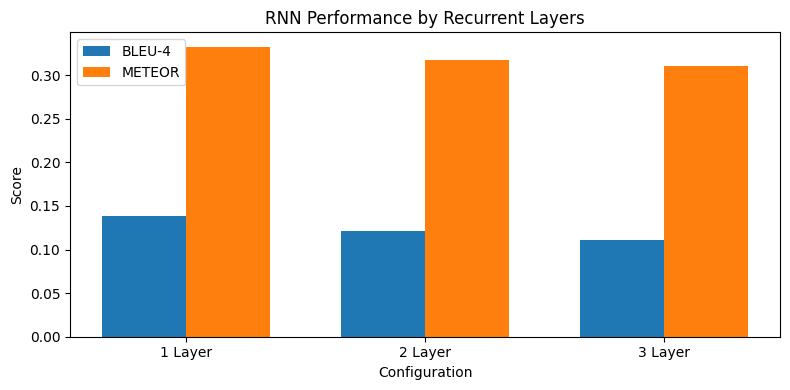

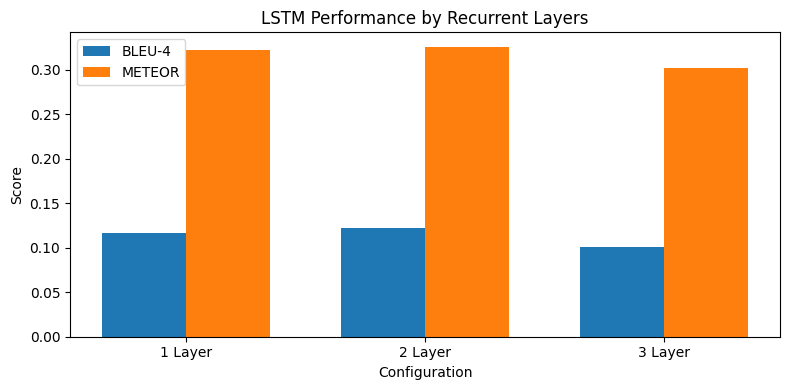


[SUCCESS] All RNN/LSTM visualizations saved to:
c:\Users\HP\Documents\Semester 6\ML\Tubes 2\ML-Tubes-2_RecursiveLearnaholic\reports\figures\rnn


In [8]:
for recur_type in ["rnn", "lstm"]:
    subset = layer_df[
        layer_df["recur_type"] == recur_type
    ].sort_values("recur_layers")

    labels = [
        f"{layer} Layer"
        for layer in subset["recur_layers"]
    ]

    bleu_values = subset["bleu4"].tolist()
    meteor_values = subset["meteor"].tolist()

    plot_metric_pairs(
        labels=labels,
        left_values=bleu_values,
        right_values=meteor_values,
        left_label="BLEU-4",
        right_label="METEOR",
        title=f"{recur_type.upper()} Performance by Recurrent Layers",
        ylabel="Score",
        filename=f"{recur_type}_recurrent_layers_bleu_meteor.png"
    )

print(f"\n[SUCCESS] All RNN/LSTM visualizations saved to:\n{SAVE_DIR}")

In [9]:
def load_epoch_log(recur_type, layers, hidden_size):
    """
    Load epoch log CSV for a specific configuration.
    """

    filename = (
        f"{recur_type}_layers{layers}"
        f"_hidden{hidden_size}_len33_epoch_log.csv"
    )

    path = RNN_TABLE_DIR / filename

    return pd.read_csv(path)

def plot_training_curves(
    configs,
    metric,
    title,
    filename
):
    """
    Plot training curves for multiple configurations.

    configs format:
    [
        ("rnn", 1, 128),
        ("rnn", 2, 128),
    ]
    """

    plt.figure(figsize=(8, 5))

    for recur_type, layers, hidden_size in configs:

        df = load_epoch_log(
            recur_type,
            layers,
            hidden_size
        )

        label = (
            f"{recur_type.upper()} "
            f"{layers}L-{hidden_size}H"
        )

        plt.plot(
            df["epoch"],
            df[metric],
            label=label
        )

    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " ").title())

    plt.title(title)

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        SAVE_DIR / filename,
        dpi=160
    )

    plt.show()

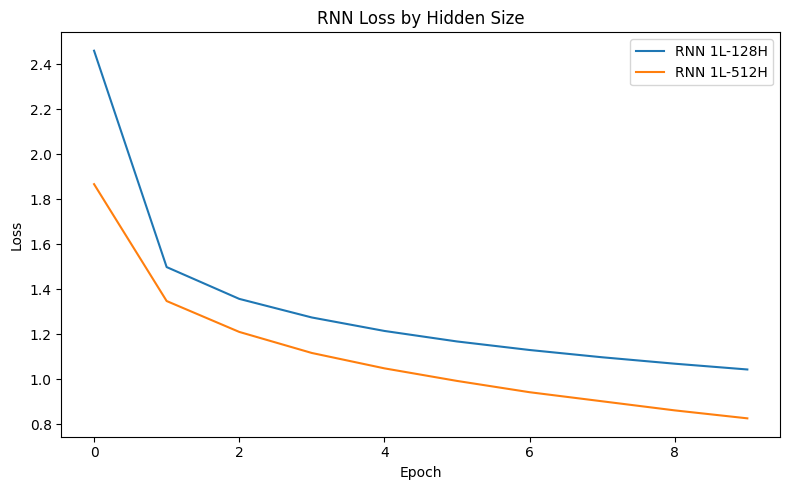

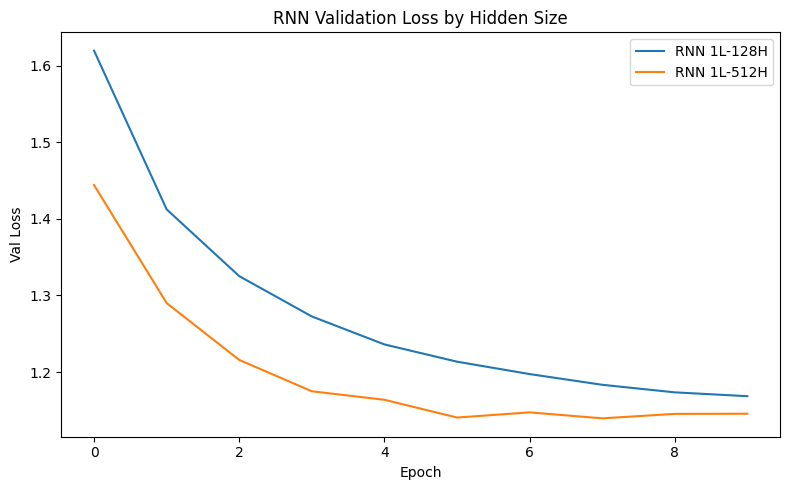

In [14]:
rnn_hidden_configs = [
    ("rnn", 1, 128),
    ("rnn", 1, 512),
]

plot_training_curves(
    configs=rnn_hidden_configs,
    metric="loss",
    title="RNN Loss by Hidden Size",
    filename="rnn_hidden_size_loss.png"
)

plot_training_curves(
    configs=rnn_hidden_configs,
    metric="val_loss",
    title="RNN Validation Loss by Hidden Size",
    filename="rnn_hidden_size_val_loss.png"
)

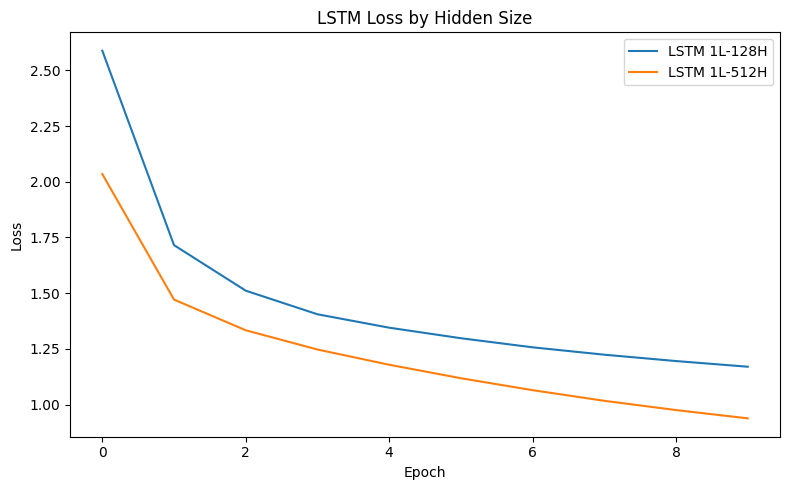

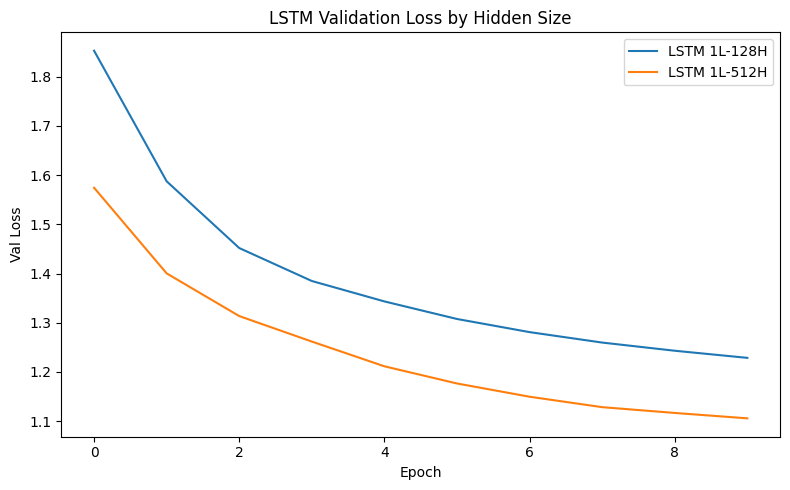

In [15]:
lstm_hidden_configs = [
    ("lstm", 1, 128),
    ("lstm", 1, 512),
]

plot_training_curves(
    configs=lstm_hidden_configs,
    metric="loss",
    title="LSTM Loss by Hidden Size",
    filename="lstm_hidden_size_loss.png"
)

plot_training_curves(
    configs=lstm_hidden_configs,
    metric="val_loss",
    title="LSTM Validation Loss by Hidden Size",
    filename="lstm_hidden_size_val_loss.png"
)


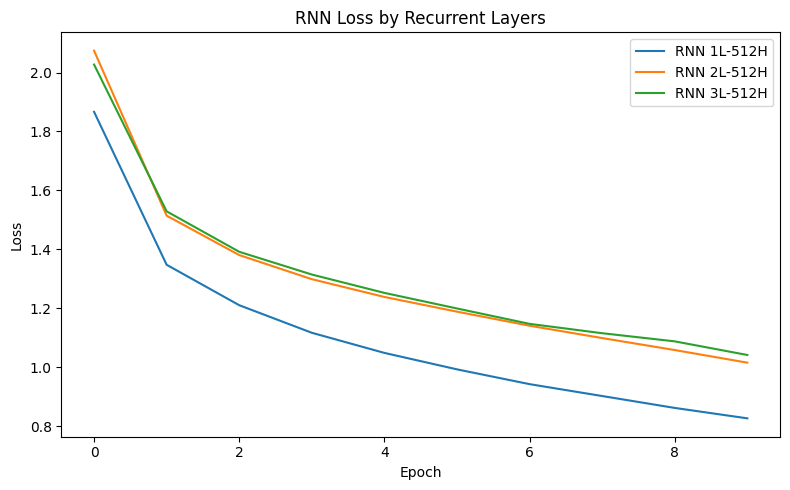

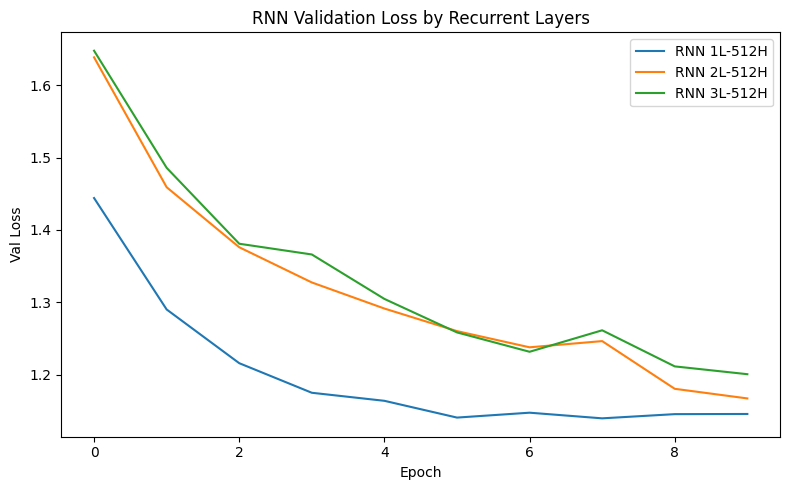

In [16]:
rnn_layer_configs = [
    ("rnn", 1, 512),
    ("rnn", 2, 512),
    ("rnn", 3, 512),
]

plot_training_curves(
    configs=rnn_layer_configs,
    metric="loss",
    title="RNN Loss by Recurrent Layers",
    filename="rnn_recurrent_layers_loss.png"
)

plot_training_curves(
    configs=rnn_layer_configs,
    metric="val_loss",
    title="RNN Validation Loss by Recurrent Layers",
    filename="rnn_recurrent_layers_val_loss.png"
)

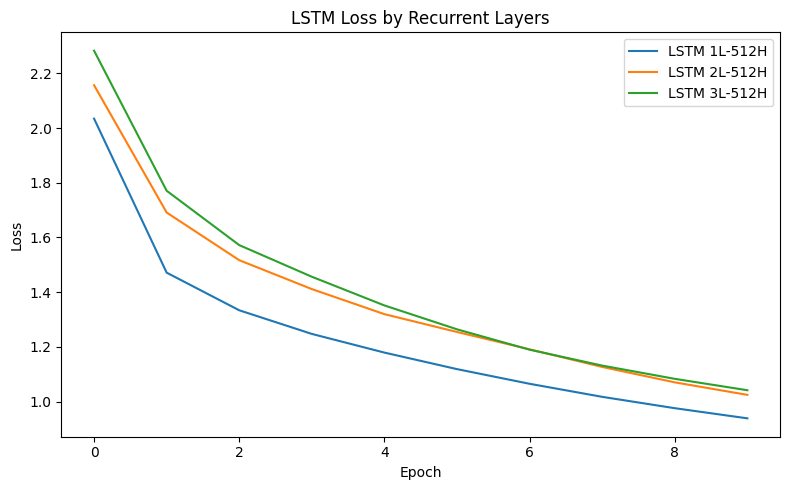

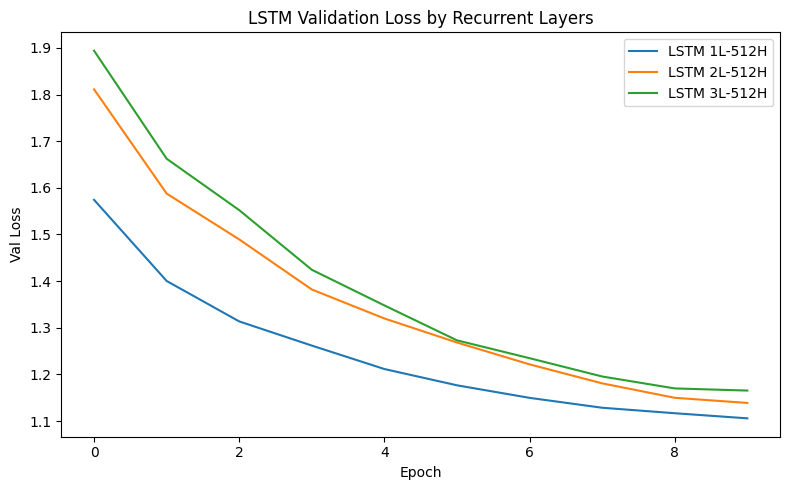


[SUCCESS] All loss visualizations saved to:
c:\Users\HP\Documents\Semester 6\ML\Tubes 2\ML-Tubes-2_RecursiveLearnaholic\reports\figures\rnn


In [17]:
lstm_layer_configs = [
    ("lstm", 1, 512),
    ("lstm", 2, 512),
    ("lstm", 3, 512),
]

plot_training_curves(
    configs=lstm_layer_configs,
    metric="loss",
    title="LSTM Loss by Recurrent Layers",
    filename="lstm_recurrent_layers_loss.png"
)

plot_training_curves(
    configs=lstm_layer_configs,
    metric="val_loss",
    title="LSTM Validation Loss by Recurrent Layers",
    filename="lstm_recurrent_layers_val_loss.png"
)

print(
    f"\n[SUCCESS] All loss visualizations saved to:\n{SAVE_DIR}"
)

In [20]:
summary_df = (
    result_df
    .groupby("recur_type", as_index=False)
    [["time_s", "bleu4", "meteor"]]
    .mean()
)

display(summary_df)

,recur_type,time_s,bleu4,meteor
0,lstm,36.504043,0.113196,0.316634
1,rnn,69.745811,0.123632,0.320208


In [21]:
def plot_rnn_vs_lstm_metric(
    metric,
    ylabel,
    title,
    filename
):
    plt.figure(figsize=(5, 4))

    plt.bar(
        summary_df["recur_type"].str.upper(),
        summary_df[metric]
    )

    plt.xlabel("Model Type")
    plt.ylabel(ylabel)

    plt.title(title)

    plt.tight_layout()

    plt.savefig(
        SAVE_DIR / filename,
        dpi=160
    )

    plt.show()

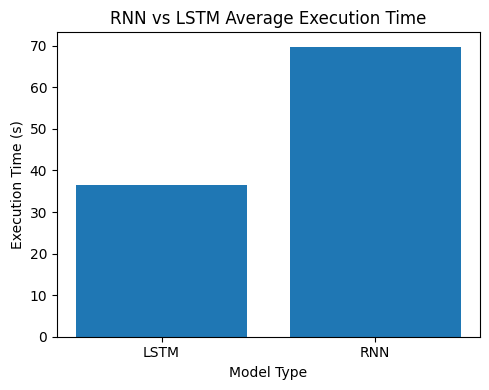

In [22]:
plot_rnn_vs_lstm_metric(
    metric="time_s",
    ylabel="Execution Time (s)",
    title="RNN vs LSTM Average Execution Time",
    filename="rnn_vs_lstm_execution_time.png"
)

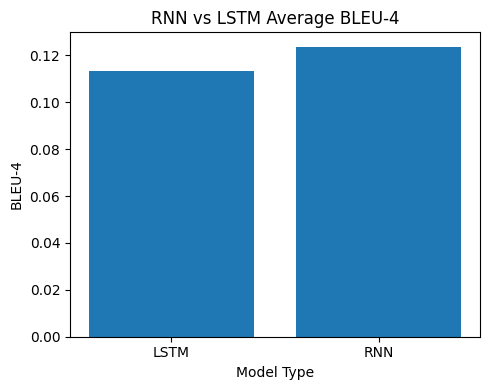

In [23]:
plot_rnn_vs_lstm_metric(
    metric="bleu4",
    ylabel="BLEU-4",
    title="RNN vs LSTM Average BLEU-4",
    filename="rnn_vs_lstm_bleu4.png"
)

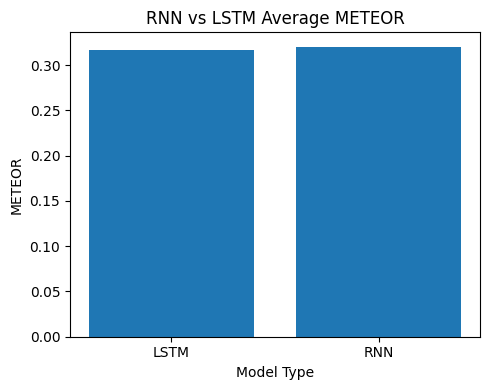

In [24]:
plot_rnn_vs_lstm_metric(
    metric="meteor",
    ylabel="METEOR",
    title="RNN vs LSTM Average METEOR",
    filename="rnn_vs_lstm_meteor.png"
)

In [25]:
def get_average_loss_curve(recur_type, metric):
    """
    Compute average loss curve for all configurations
    of a recurrent type.
    """

    files = sorted(
        RNN_TABLE_DIR.glob(
            f"{recur_type}_layers*_epoch_log.csv"
        )
    )

    curves = []

    for file in files:
        df = pd.read_csv(file)
        curves.append(df[metric].values)

    curves = pd.DataFrame(curves)

    return curves.mean(axis=0)

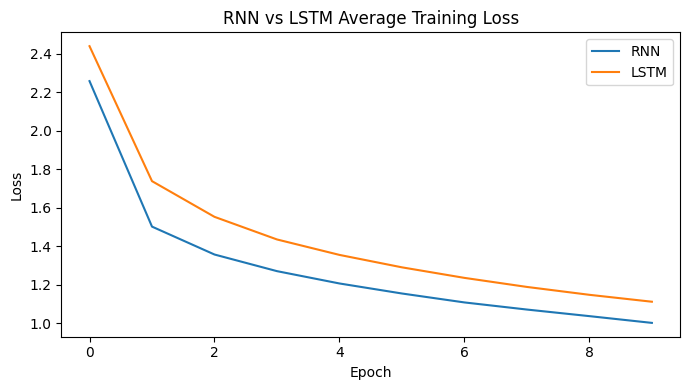

In [26]:
rnn_loss = get_average_loss_curve("rnn", "loss")
lstm_loss = get_average_loss_curve("lstm", "loss")

epochs = range(len(rnn_loss))

plt.figure(figsize=(7, 4))

plt.plot(epochs, rnn_loss, label="RNN")
plt.plot(epochs, lstm_loss, label="LSTM")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("RNN vs LSTM Average Training Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    SAVE_DIR / "rnn_vs_lstm_loss.png",
    dpi=160
)

plt.show()

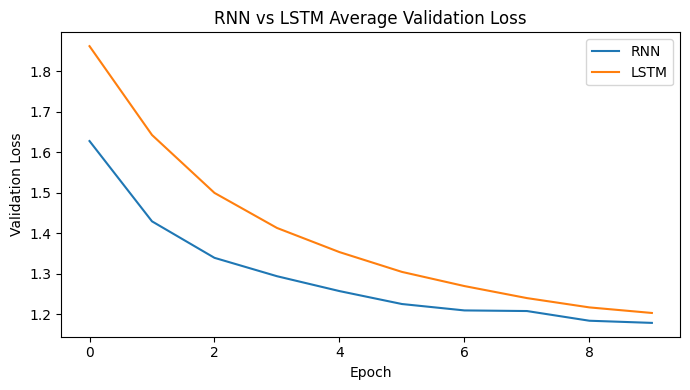


[SUCCESS] RNN vs LSTM comparison graphs saved to:
c:\Users\HP\Documents\Semester 6\ML\Tubes 2\ML-Tubes-2_RecursiveLearnaholic\reports\figures\rnn


In [27]:
rnn_val_loss = get_average_loss_curve("rnn", "val_loss")
lstm_val_loss = get_average_loss_curve("lstm", "val_loss")

epochs = range(len(rnn_val_loss))

plt.figure(figsize=(7, 4))

plt.plot(epochs, rnn_val_loss, label="RNN")
plt.plot(epochs, lstm_val_loss, label="LSTM")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title("RNN vs LSTM Average Validation Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    SAVE_DIR / "rnn_vs_lstm_val_loss.png",
    dpi=160
)

plt.show()

print(
    f"\n[SUCCESS] RNN vs LSTM comparison graphs saved to:\n{SAVE_DIR}"
)